# Nonlinear-DGP extension — quadratic *lagged-state* VAR(4)

Moves the functional misspecification out of the **innovation** (Extension 2's mean-zero shock-quadratic, which left both estimators undisturbed) and into the **conditional mean**. The DGP is the baseline VAR(4) plus a standardised, centred square of the first variable's first lag, entering equation 2:
$$ y_t=\sum_{i=1}^4 A_i y_{t-i}+\gamma\,\big(0,\ (y_{1,t-1}/\sigma_1)^2-1\big)'+u_t,\qquad u_t=B\varepsilon_t,\ \varepsilon_t\sim\mathcal N(0,I_2),$$
with $\sigma_1$ the first variable's *linear* stationary SD and $\gamma\in\{0,0.3,0.6\}$ ($\gamma=0$ nests the baseline VAR(4)).

Because the squared term is a function of the **past state**, the conditional mean is genuinely nonlinear — a real misspecification of the linear model, not approximable by higher-order linear VARs. **Estimand.** Both *linear* LP and *linear* VAR target the same best linear approximation (Plagborg-Møller & Wright: *linear* LP and VAR estimate the same impulse responses even when the DGP is nonlinear — the adjective is on the estimators, not the DGP). We compute that projection per $\gamma$ by **pooled-moments OLS** (§0) and verify LP agrees with it.

**The two findings.** (i) The best linear projection is **nearly $\gamma$-invariant**: a centred square is almost orthogonal to the linear lag space, so it barely moves the *point* estimand — the bias channel is nearly shut (and §4 confirms it vanishes asymptotically: no bias floor). (ii) But unlike the *iid* shock-quadratic, a lagged-state square is a function of the serially-correlated state, so it injects **conditional heteroskedasticity** into the projection residuals (their variance scales with $y_{1,t-1}^2$). This is the genuine inference channel: VAR's homoskedastic delta-method CIs **under-cover ever more severely as $\gamma$ grows**, while LP's heteroskedasticity-robust CIs **hold up** — the first setting in this study where LP's robustness yields a real advantage.

**Stationarity.** The lag-quadratic is explosive at high persistence (the reason the thesis text avoided it): at $\rho=0.95$ every long path diverges, and even $\rho=0.75$ explodes in practice. This extension therefore runs only at the stationary **LOW ($\rho=0.5$) and MID ($\rho=0.7$)** scenarios. The process is *metastable* even there — stationary at empirical $T\le500$ but explosive over very long horizons — so the estimand is computed by pooled-moments projection (§0) rather than a single ultra-long path; divergent paths are returned as NaN by the simulator and dropped, with their rate reported as a stationarity diagnostic.

In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

from mcsim.dgp import (QuadLagVARSpec, simulate_quad_lag_var, scale_to_persistence,
                       spectral_radius, var_ma_matrices, var_irf, VARSpec)
from mcsim.estimators import estimate_lp_irf, estimate_var_irf, fit_var_ols
from mcsim.simulation import MCConfig, run
from mcsim.coverage import var_theta_se, lp_theta_se

## 0. Model parameters, estimand, and stationarity check

In [2]:
# Persistence scenario: only LOW (rho=0.5) and MID (rho=0.7) are stationary for the
# lag-quadratic -- rho>=0.75 explodes, so HIGH is dropped in this extension.
Scenario = "MID"

In [3]:
SEED = 42                                            # master RNG seed for all stochastic processes
P = 4
H = 20
RHO_SCENARIO = {"LOW": 0.5, "MID": 0.7}   # only stationary scenarios; rho>=0.75 explodes for the lag-quadratic
RHO = RHO_SCENARIO[Scenario]

T = [250, 10000]
GAMMAS = [0.0, 0.3, 0.6]          # nonlinearity strength (gamma=0 nests the baseline VAR(4))
T_SHOW = 10000

M  = np.array([[0.50, 0.10], [0.10, 0.50]])
A0 = np.array([M, 0.4 * M, 0.2 * M, 0.1 * M])
B  = np.array([[1.0, 0.0], [0.5, 1.0]])
A_RHO = scale_to_persistence(A0, RHO)

DGPS = {g: QuadLagVARSpec(A=A_RHO, B=B, gamma=g) for g in GAMMAS}
SIGMA1 = DGPS[0.0].sigma1          # first variable's linear stationary SD (the standardiser)

hgrid = np.arange(H + 1)
cg = {g: plt.cm.viridis(i / max(len(GAMMAS) - 1, 1)) for i, g in enumerate(GAMMAS)}

print(f"Scenario={Scenario}  rho={RHO}  AR spectral radius={spectral_radius(A_RHO):.3f}  sigma1={SIGMA1:.3f}")
N_REPS = 5000

Scenario=MID  rho=0.7  AR spectral radius=0.700  sigma1=1.135


### The estimand: best linear projection by pooled moments

The squared lag makes the conditional mean nonlinear, so the estimand — the best **linear** projection both LP and VAR target — has no closed form and is *not* the baseline IRF. We estimate it consistently from **pooled moments**: accumulate $X'X,\ X'Y,\ Y'Y$ over many independent moderate-$T$ samples (dropping the rare divergent ones), solve once for the population OLS coefficients $A^{\mathrm{proj}}$ and residual covariance $\Sigma$, and form $\theta_h=(\Psi_h(A^{\mathrm{proj}})\,\mathrm{chol}\,\Sigma)$. This avoids needing a single ultra-long path (impossible here — the process is *metastable*, stationary at empirical $T$ but explosive over very long horizons). The printout reports the kept-path fraction (a stationarity diagnostic) and verifies a large-sample LP fit lands on the same projection (PMW).

In [4]:
def _design(y, p):
    """VAR(p) regression design (with intercept) for a single sample."""
    Tn, k = y.shape
    X = np.empty((Tn - p, p * k))
    for i in range(1, p + 1):
        X[:, (i - 1) * k:i * k] = y[p - i:Tn - i]
    return np.column_stack([np.ones(Tn - p), X]), y[p:]


def pooled_projection(spec, Tmod=500, R=4000, seed=SEED, p=P, horizon=H):
    """Population best-linear-projection structural IRF tensor (H+1,k,k), by pooled moments.

    Returns (theta_full, kept_fraction). Divergent (NaN) paths are skipped; the
    projection is taken over the quasi-stationary ensemble the finite-T data live in.
    """
    seeds = np.random.SeedSequence(seed).spawn(R)

    def one(s):
        y = simulate_quad_lag_var(spec, Tmod, np.random.default_rng(s))
        if not np.isfinite(y).all():
            return None
        X, Y = _design(y, p)
        with np.errstate(all="ignore"):
            return X.T @ X, X.T @ Y, Y.T @ Y, len(Y)

    out = [o for o in Parallel(n_jobs=-1)(delayed(one)(s) for s in seeds) if o is not None]
    Sxx = sum(o[0] for o in out); Sxy = sum(o[1] for o in out)
    Syy = sum(o[2] for o in out); N = sum(o[3] for o in out)
    beta = np.linalg.solve(Sxx, Sxy)                       # (1+pk, k)
    Sig = (Syy - Sxy.T @ beta) / N
    k = spec.k
    Acoef = beta[1:].reshape(p, k, k).transpose(0, 2, 1)   # -> (lag, equation, variable)
    theta = var_ma_matrices(Acoef, horizon) @ np.linalg.cholesky(Sig)
    return theta, len(out) / R

truth_byGamma, kept = {}, {}
for g in GAMMAS:
    truth_byGamma[g], kept[g] = pooled_projection(DGPS[g], Tmod=500, R=4000)
TRUTH0 = {g: truth_byGamma[g][:, 0, 0] for g in GAMMAS}    # var1 <- shock1 (headline estimand)

base = var_irf(VARSpec(A_RHO, B), H)                        # linear (gamma=0) baseline IRF, for reference
print("gamma | kept-path fraction (stationarity) | max|projection - baseline| (estimand shift)")
for g in GAMMAS:
    print(f"  {g:<4}        {kept[g]:.3f}                       {np.max(np.abs(TRUTH0[g] - base)):.4f}")

# Validate PMW: a large-sample LP(4) fit agrees with the pooled projection.
def _lp_big(s, spec):
    y = simulate_quad_lag_var(spec, 3000, np.random.default_rng(s))
    if not np.isfinite(y).all():
        return None
    with np.errstate(all="ignore"):
        return estimate_lp_irf(y, P, H)
for g in GAMMAS:
    lo = [o for o in Parallel(n_jobs=-1)(delayed(_lp_big)(s, DGPS[g])
          for s in np.random.SeedSequence(SEED).spawn(80)) if o is not None]
    print(f"  gamma={g}: max|LP(large-T) - projection| = {np.max(np.abs(np.nanmean(lo, 0) - TRUTH0[g])):.4f}")

gamma | kept-path fraction (stationarity) | max|projection - baseline| (estimand shift)
  0.0         1.000                       0.0012
  0.3         1.000                       0.0013
  0.6         1.000                       0.0060
  gamma=0.0: max|LP(large-T) - projection| = 0.0047
  gamma=0.3: max|LP(large-T) - projection| = 0.0049
  gamma=0.6: max|LP(large-T) - projection| = 0.0055


## 1. DGP — invariant estimand, heteroskedastic residuals

**Left:** the linear-projection estimand $\theta_h$ (var1 $\leftarrow$ shock1) for each $\gamma$. The curves nearly coincide on the $\gamma=0$ baseline, so the *point* estimand is almost $\gamma$-invariant (a centred square is roughly orthogonal to the linear lag space). **Middle:** the ACF of the **squared** second-equation residual, which lifts above the white-noise band as $\gamma$ grows, the signature of conditional heteroskedasticity (the residual variance scales with $y_{1,t-1}^2$). **Right:** the same diagnostic on the **level** residual, which stays inside the band, confirming the conditional mean is captured and only the variance moves with $\gamma$. The shaded region is the Bartlett $\pm 1.96/\sqrt{N}$ white-noise band.

/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_65748/717206973.py:15: RuntimeWarning: divide by zero encountered in matmul
  x = x - x.mean(); v = x @ x
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_65748/717206973.py:15: RuntimeWarning: overflow encountered in matmul
  x = x - x.mean(); v = x @ x
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_65748/717206973.py:15: RuntimeWarning: invalid value encountered in matmul
  x = x - x.mean(); v = x @ x
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_65748/717206973.py:16: RuntimeWarning: divide by zero encountered in matmul
  return np.array([1.0] + [(x[l:] @ x[:-l]) / v for l in range(1, L + 1)])
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_65748/717206973.py:16: RuntimeWarning: overflow encountered in matmul
  return np.array([1.0] + [(x[l:] @ x[:-l]) / v for l in range(1, L + 1)])
/var/folders/9m/p384f19n5hn9s280538vqncr0000gn/T/ipykernel_65748/717206973.py:16: RuntimeWarning: 

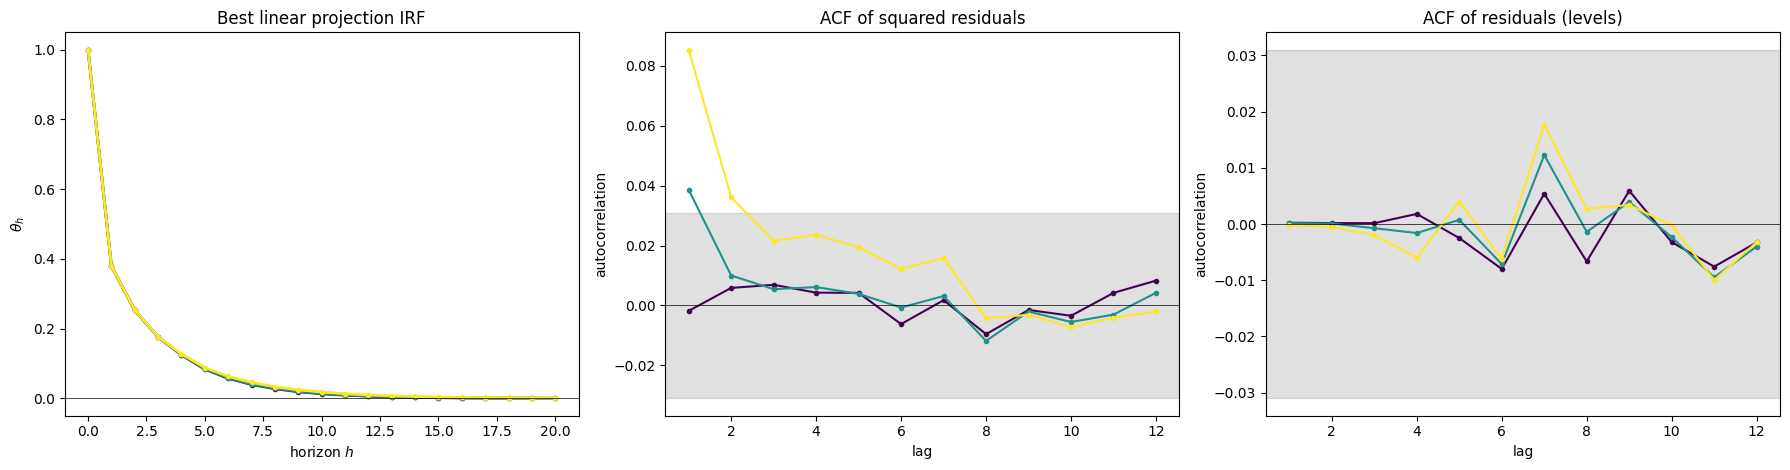

stationarity (kept-path fraction): γ=0.0:1.000  γ=0.3:1.000  γ=0.6:1.000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# (a) near-invariant linear estimand
ax = axes[0]
for g in GAMMAS:
    lab = "γ=0 (baseline)" if g == 0 else f"γ={g}"
    ax.plot(hgrid, TRUTH0[g], "o-", lw=2.0, ms=3, color=cg[g], label=lab)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Best linear projection IRF")
ax.set_xlabel("horizon $h$"); ax.set_ylabel(r"$\theta_h$")

# (b) & (c) residual diagnostics on the same paths: squares cluster (conditional heteroskedasticity),
#           levels stay white (linear conditional mean is captured)
def _acf(x, L=12):
    x = x - x.mean(); v = x @ x
    return np.array([1.0] + [(x[l:] @ x[:-l]) / v for l in range(1, L + 1)])
for g in GAMMAS:
    acf_sq, acf_lvl = [], []
    for s in np.random.SeedSequence(SEED).spawn(64):           # oversample: metastable paths are dropped below
        y = simulate_quad_lag_var(DGPS[g], 4000, np.random.default_rng(s))
        if not np.isfinite(y).all() or np.abs(y).max() > 1e6:  # drop divergent / mid-explosion paths,
            continue                                           # finite-but-huge values overflow res**2 in the ACF
        with np.errstate(all="ignore"):
            _, _, res = fit_var_ols(y, P)
        acf_sq.append(_acf(res[:, 1] ** 2, 12))                # squared eq-2 residual -> conditional variance
        acf_lvl.append(_acf(res[:, 1], 12))                    # level   eq-2 residual -> should stay white
        if len(acf_sq) >= 8:
            break
    lab = "γ=0 (baseline)" if g == 0 else f"γ={g}"
    axes[1].plot(range(1, 13), np.nanmean(acf_sq, 0)[1:], "o-", ms=3, color=cg[g],
                 label=lab + f" (n={len(acf_sq)})")
    axes[2].plot(range(1, 13), np.nanmean(acf_lvl, 0)[1:], "o-", ms=3, color=cg[g],
                 label=lab + f" (n={len(acf_lvl)})")

# Bartlett white-noise band, 0 +/- 1.96/sqrt(N). (b) squares break out -> conditional
# heteroskedasticity, (c) levels stay inside -> conditional mean captured, only variance moves.
nb_acf = 4000 - P
band = 1.96 / np.sqrt(nb_acf)
for ax, ttl in ((axes[1], "ACF of squared residuals"), (axes[2], "ACF of residuals (levels)")):
    ax.axhline(0, color="k", lw=0.5)
    ax.axhspan(-band, band, color="black", alpha=0.12, label="95% white-noise band")
    ax.set_title(ttl); ax.set_xlabel("lag"); ax.set_ylabel("autocorrelation")
fig.tight_layout()
plt.savefig(f"../../figures/NonLinear_DGP/NON_LIN_IRF_rho={RHO}.png")
plt.show()
print("stationarity (kept-path fraction): " + "  ".join(f"γ={g}:{kept[g]:.3f}" for g in GAMMAS))

## 2. Monte Carlo — LP(4) + VAR(q) sweep × nonlinearity × sample size

Fixed **LP(4)** and the full **VAR(q) sweep** ($q=1\ldots23$) on the nonlinear data, applied unchanged, scored against the $\gamma$-dependent projection estimand `TRUTH0`. Divergent paths surface as estimator failures; their count is reported per cell (a stationarity check at each $T$).

In [6]:
VAR_ORDERS = list(range(1, P + H))

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in VAR_ORDERS})


def quad_lag_dgp(rng, Tlen, spec):
    return simulate_quad_lag_var(spec, Tlen, rng)


results, rmse = {}, {}
for g in GAMMAS:
    truth = TRUTH0[g]
    for Tval in T:
        cfg = MCConfig(n_reps=N_REPS, T=Tval, horizon=H, seed=SEED, n_jobs=-1,
                       progress=True, estimators=estimators)
        res = run(partial(quad_lag_dgp, spec=DGPS[g]), cfg)
        results[(g, Tval)] = res
        rmse[(g, Tval)] = {nm: np.sqrt(np.nanmean((st - truth) ** 2, axis=0))
                           for nm, st in res["irfs"].items()}
        nfail = res["n_failures"].get("VAR(4)", 0)
        print(f"gamma={g:<4} T={Tval:>4}: done  |  divergent/failed reps (VAR4): {nfail}/{N_REPS}")

MC reps: 100%|██████████| 5000/5000 [00:05<00:00, 869.24it/s]


gamma=0.0  T= 250: done  |  divergent/failed reps (VAR4): 0/5000


MC reps: 100%|██████████| 5000/5000 [01:00<00:00, 82.97it/s]


gamma=0.0  T=10000: done  |  divergent/failed reps (VAR4): 0/5000


MC reps: 100%|██████████| 5000/5000 [00:05<00:00, 920.83it/s] 


...

gamma=0.3  T=10000: done  |  divergent/failed reps (VAR4): 0/5000


MC reps: 100%|██████████| 5000/5000 [00:05<00:00, 855.71it/s]


gamma=0.6  T= 250: done  |  divergent/failed reps (VAR4): 0/5000


MC reps: 100%|██████████| 5000/5000 [01:06<00:00, 75.36it/s]


gamma=0.6  T=10000: done  |  divergent/failed reps (VAR4): 14/5000


## 3. RMSE comparison

Complexity frontier at $T=250$, one curve per $\gamma$ (LP(4) dashed, same colour). The nonlinearity is not a lag-length problem, so extra lags don't lower the floor; RMSE rises with $\gamma$ through the inflated residual variance. The table reports every $(\gamma,T)$ cell.

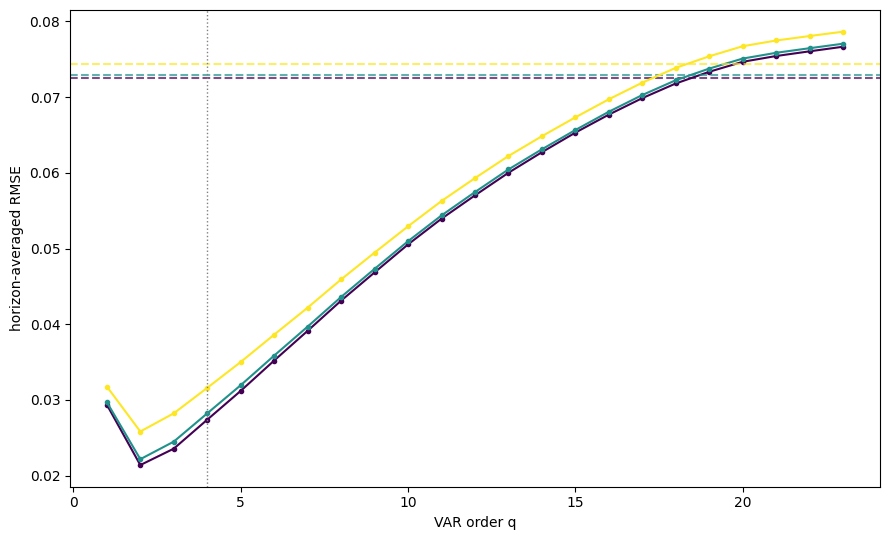

 gamma     T    LP(4)   VAR(4)        bestVAR   LP-VAR4
--------------------------------------------------------
   0.0   250    0.072    0.027   VAR(2)=0.021    +0.045
   0.0 10000    0.011    0.004   VAR(4)=0.004    +0.007
   0.3   250    0.073    0.028   VAR(2)=0.022    +0.045
   0.3 10000    0.011    0.004   VAR(4)=0.004    +0.007
   0.6   250    0.074    0.032   VAR(2)=0.026    +0.043
   0.6 10000    0.011    0.005   VAR(4)=0.005    +0.006
(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)


In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for g in GAMMAS:
    rm = rmse[(g, T[0])]
    ax.plot(VAR_ORDERS, [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS], "o-", ms=3, color=cg[g],
            label=("γ=0 (baseline)" if g == 0 else f"γ={g}"))
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=cg[g], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)
# ax.set_title(f"Complexity frontier across γ (T={T_SHOW}; solid=VAR(q), dashed=LP(4)), ρ={RHO} ({Scenario})")
ax.set_xlabel("VAR order q"); ax.set_ylabel("horizon-averaged RMSE")
fig.tight_layout()
plt.savefig(f"../../figures/NonLinear_DGP/NON_LIN_COMPLEXITY_FRONTIER_rho={RHO}_T={T[0]}.png")
plt.show()

print(f"{'gamma':>6} {'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>14} {'LP-VAR4':>9}")
print("-" * 56)
for g in GAMMAS:
    for Tval in T:
        rm = rmse[(g, Tval)]
        lp = float(np.mean(rm["LP(4)"])); v4 = float(np.mean(rm["VAR(4)"]))
        avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
        bq = min(avgs, key=avgs.get)
        print(f"{g:>6} {Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>14} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

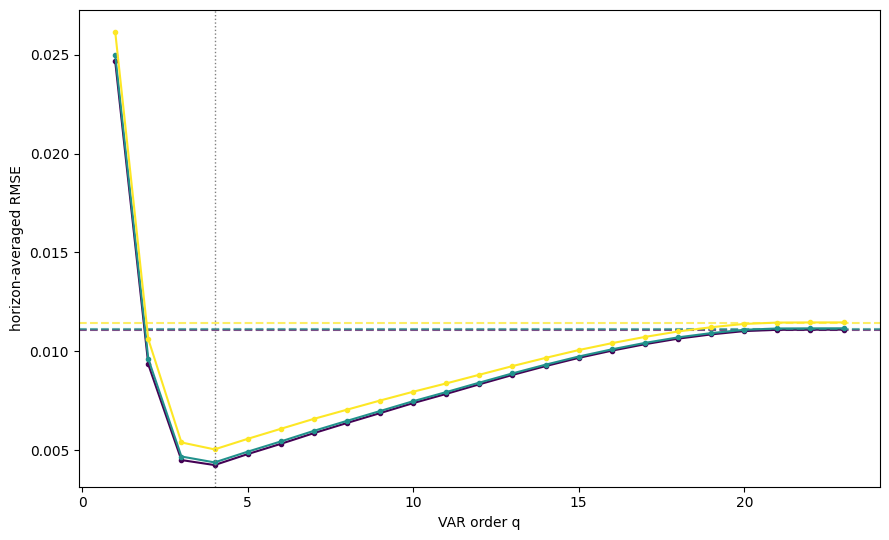

 gamma     T    LP(4)   VAR(4)        bestVAR   LP-VAR4
--------------------------------------------------------
   0.0   250    0.072    0.027   VAR(2)=0.021    +0.045
   0.0 10000    0.011    0.004   VAR(4)=0.004    +0.007
   0.3   250    0.073    0.028   VAR(2)=0.022    +0.045
   0.3 10000    0.011    0.004   VAR(4)=0.004    +0.007
   0.6   250    0.074    0.032   VAR(2)=0.026    +0.043
   0.6 10000    0.011    0.005   VAR(4)=0.005    +0.006
(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)


In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for g in GAMMAS:
    rm = rmse[(g, T[1])]
    ax.plot(VAR_ORDERS, [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS], "o-", ms=3, color=cg[g],
            label=("γ=0 (baseline)" if g == 0 else f"γ={g}"))
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=cg[g], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)
# ax.set_title(f"Complexity frontier across γ (T={T_SHOW}; solid=VAR(q), dashed=LP(4)), ρ={RHO} ({Scenario})")
ax.set_xlabel("VAR order q"); ax.set_ylabel("horizon-averaged RMSE")
fig.tight_layout()
plt.savefig(f"../../figures/NonLinear_DGP/NON_LIN_COMPLEXITY_FRONTIER_rho={RHO}_T={T[1]}.png")
plt.show()

print(f"{'gamma':>6} {'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>14} {'LP-VAR4':>9}")
print("-" * 56)
for g in GAMMAS:
    for Tval in T:
        rm = rmse[(g, Tval)]
        lp = float(np.mean(rm["LP(4)"])); v4 = float(np.mean(rm["VAR(4)"]))
        avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
        bq = min(avgs, key=avgs.get)
        print(f"{g:>6} {Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>14} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

## 5. Point-estimation metrics ($\gamma=0.6$)

Bias / variance / MSE / RMSE at the strongest nonlinearity. Bias stays small and $\gamma$-stable (both estimators consistent for the projection); the action is in variance.

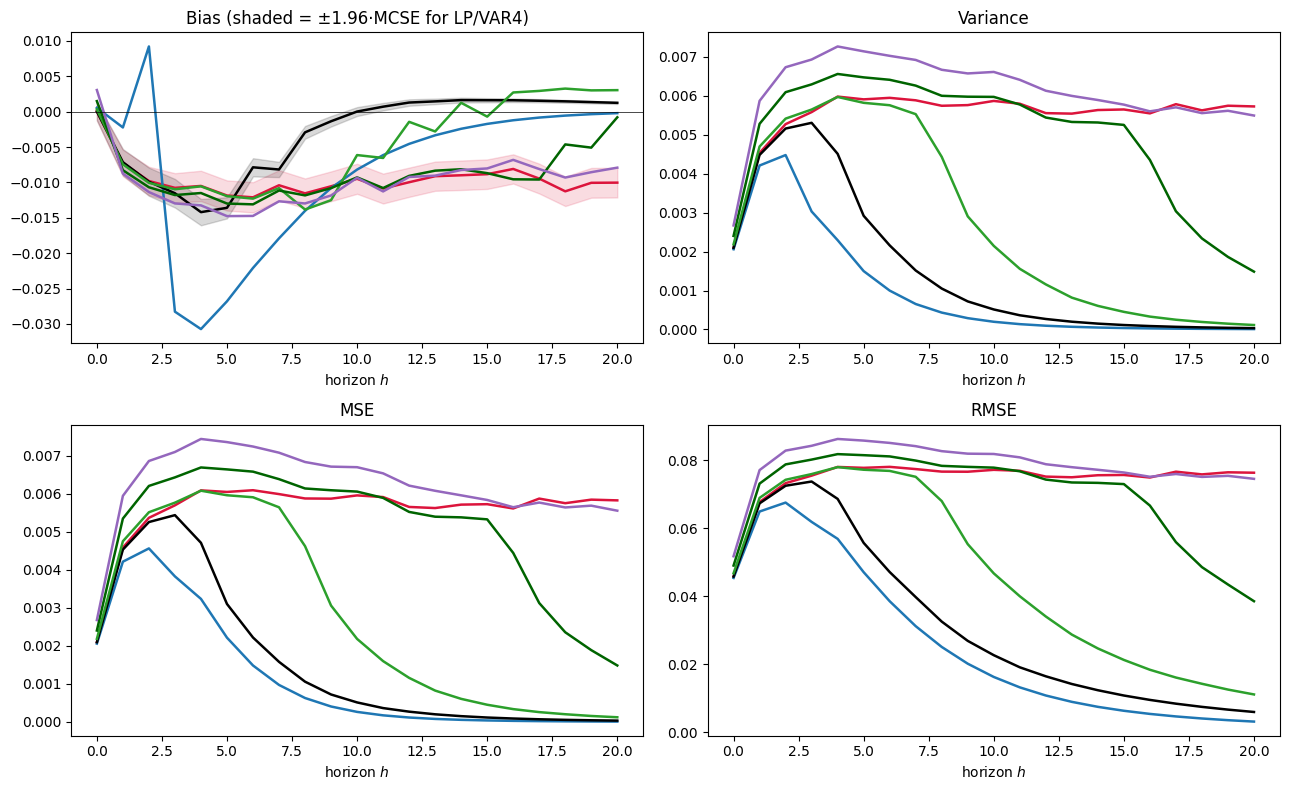

h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)   -0.0072  0.0677 -0.0115  0.0767 -0.0100  0.0763
VAR(2)  -0.0022  0.0649 -0.0140  0.0251 -0.0002  0.0031
VAR(4)  -0.0071  0.0673 -0.0029  0.0326  0.0013  0.0060
VAR(8)  -0.0074  0.0689 -0.0138  0.0680  0.0031  0.0111
VAR(16) -0.0083  0.0731 -0.0118  0.0784 -0.0008  0.0385
VAR(23) -0.0087  0.0771 -0.0130  0.0827 -0.0079  0.0745

In [9]:
import pandas as pd
from IPython.display import display


def metrics(stack, truth):
    Bn = int(np.sum(~np.isnan(stack[:, 0])))
    var = np.nanvar(stack, axis=0, ddof=1)
    return dict(bias=np.nanmean(stack, axis=0) - truth, var=var,
                mse=np.nanmean((stack - truth) ** 2, axis=0),
                rmse=np.sqrt(np.nanmean((stack - truth) ** 2, axis=0)),
                mcse_bias=np.sqrt(var / Bn))


G_SHOW = 0.6
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results[(G_SHOW, T[0])]["irfs"][nm], TRUTH0[G_SHOW]) for nm in sel}

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)
for nm in ("LP(4)", "VAR(4)"):
    ax[0, 0].fill_between(hgrid, m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"], m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"],
                          color=colm[nm], alpha=0.15)
ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias (shaded = ±1.96·MCSE for LP/VAR4)")
ax[0, 1].set_title("Variance"); ax[1, 0].set_title("MSE"); ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$")
# fig.suptitle(f"Point metrics, γ={G_SHOW}, T={T_SHOW}, B={N_REPS}, ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/NonLinear_DGP/NON_LIN_POINT_ESTIMATION_rho={RHO}_T={T[0]}_B=5000_gamma={G_SHOW}.png")
plt.show()

rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in (1, 8, 20) for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T; tab.columns = pd.MultiIndex.from_tuples(tab.columns)
display(tab.round(4))

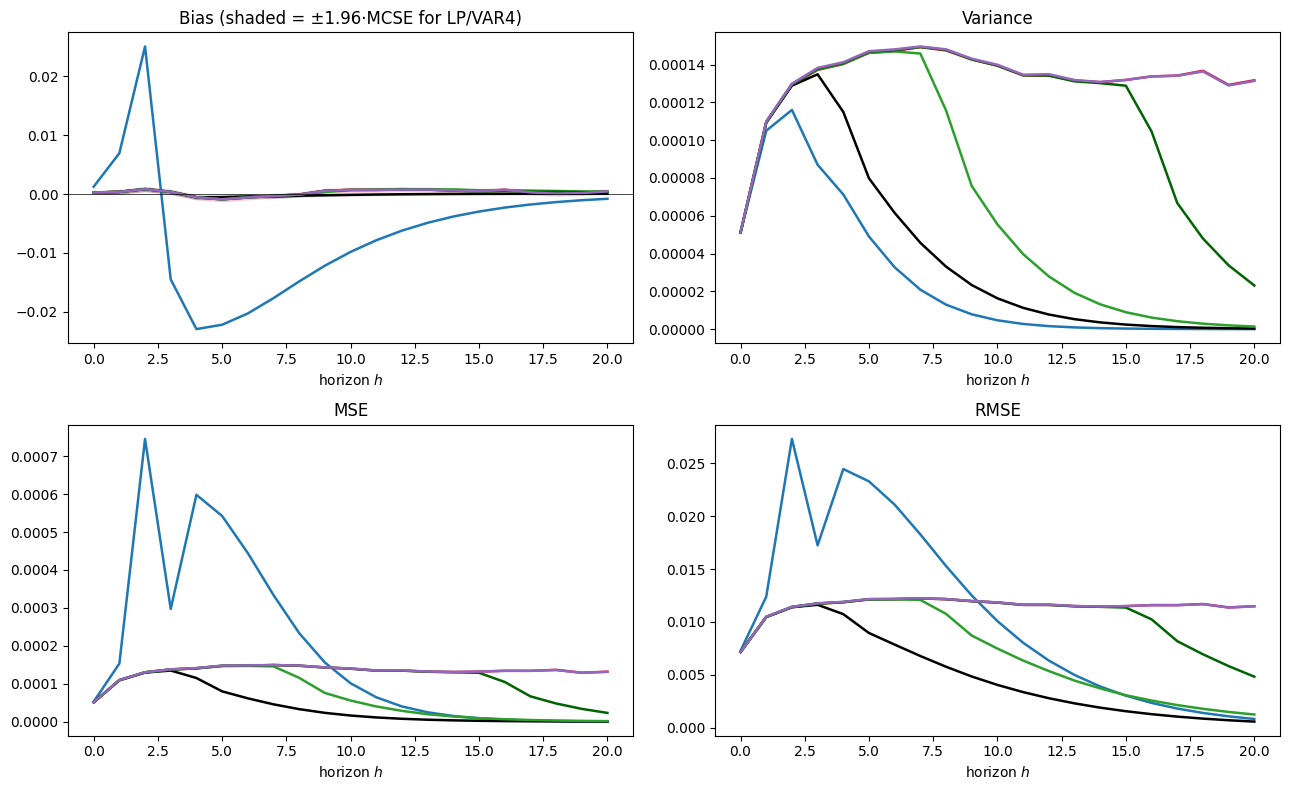

h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)    0.0004  0.0105 -0.0001  0.0121  0.0005  0.0115
VAR(2)   0.0069  0.0124 -0.0149  0.0153 -0.0008  0.0008
VAR(4)   0.0004  0.0105 -0.0003  0.0058  0.0000  0.0006
VAR(8)   0.0004  0.0105 -0.0001  0.0108  0.0004  0.0012
VAR(16)  0.0004  0.0105 -0.0001  0.0122  0.0004  0.0048
VAR(23)  0.0004  0.0105 -0.0001  0.0122  0.0005  0.0115

In [10]:
import pandas as pd
from IPython.display import display


def metrics(stack, truth):
    Bn = int(np.sum(~np.isnan(stack[:, 0])))
    var = np.nanvar(stack, axis=0, ddof=1)
    return dict(bias=np.nanmean(stack, axis=0) - truth, var=var,
                mse=np.nanmean((stack - truth) ** 2, axis=0),
                rmse=np.sqrt(np.nanmean((stack - truth) ** 2, axis=0)),
                mcse_bias=np.sqrt(var / Bn))


G_SHOW = 0.6
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results[(G_SHOW, T[1])]["irfs"][nm], TRUTH0[G_SHOW]) for nm in sel}

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)
for nm in ("LP(4)", "VAR(4)"):
    ax[0, 0].fill_between(hgrid, m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"], m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"],
                          color=colm[nm], alpha=0.15)
ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias (shaded = ±1.96·MCSE for LP/VAR4)")
ax[0, 1].set_title("Variance"); ax[1, 0].set_title("MSE"); ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$")
# fig.suptitle(f"Point metrics, γ={G_SHOW}, T={T_SHOW}, B={N_REPS}, ρ={RHO} ({Scenario})", fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/NonLinear_DGP/NON_LIN_POINT_ESTIMATION_rho={RHO}_T={T[1]}_B=5000_gamma={G_SHOW}.png")
plt.show()

rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in (1, 8, 20) for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T; tab.columns = pd.MultiIndex.from_tuples(tab.columns)
display(tab.round(4))

## 6. Coverage (the headline)

Coverage of nominal 95% CIs for the projection $\theta_h$ of variable 1 to shock 1, at the strongest nonlinearity $\gamma=0.6$, in the **same two-panel format as the baseline**. The figure compares the homoskedastic **VAR(4)** delta method, the high-order **VAR(23)**, and the heteroskedasticity-robust **LP(4)** HC1. A right panel validates the VAR(4) delta-method SE against the empirical sampling SD. The lag-quadratic makes the residual variance scale with $y_{1,t-1}^2$ (section 1), so VAR under-covers while LP holds near nominal.

cov var1 γ=0.6: 100%|██████████| 5000/5000 [01:18<00:00, 64.06it/s]


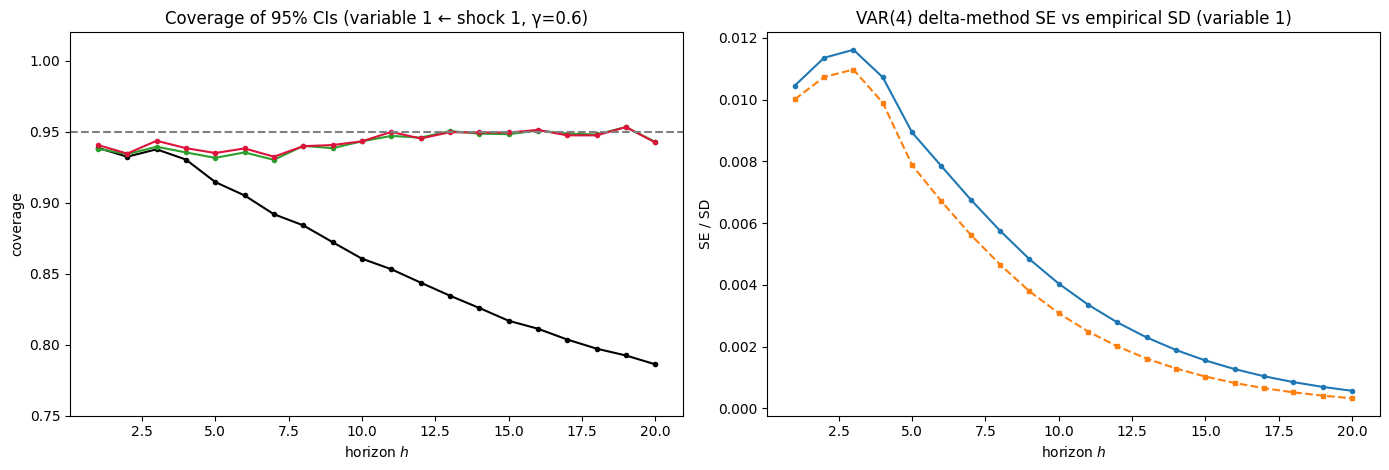

horizon-averaged coverage (h=1..20, var1, γ=0.6):  VAR(4)=0.862   VAR(23)=0.942   LP(4)=0.944


In [11]:
N_COV = 5000; Z = 1.96
GAMMA_COV = 0.6        # fixed at the strongest nonlinearity (matches the point-estimation panel)
RESP = 0               # variable 1 <- shock 1, the headline response
EST_COV = ["VAR(4)", "VAR(23)", "LP(4)"]   # same estimator set as the baseline coverage figure
cc = {"VAR(4)": "black", "VAR(23)": "tab:green", "LP(4)": "crimson"}


def _cov_rep(seed, spec):
    y = simulate_quad_lag_var(spec, T[1], np.random.default_rng(seed))
    if not np.isfinite(y).all():
        return None
    with np.errstate(all="ignore"):
        return {"VAR(4)":  var_theta_se(y, 4, H, response=RESP),
                "VAR(23)": var_theta_se(y, 23, H, response=RESP),
                "LP(4)":   lp_theta_se(y, 4, H, response=RESP)}


# Baseline-style figure for variable 1, coverage of VAR4/VAR23/LP4 plus VAR(4) SE vs empirical SD.
# h0 is a degenerate normalization point (impact-response delta-method SE -> 0), so we report
# coverage over the plateau h = 1..20 only.
reps = [r for r in Parallel(n_jobs=-1)(delayed(_cov_rep)(s, DGPS[GAMMA_COV])
        for s in tqdm(np.random.SeedSequence(SEED).spawn(N_COV), desc=f"cov var1 γ={GAMMA_COV}")) if r]
truth = TRUTH0[GAMMA_COV]
theta_s = {nm: np.array([r[nm][0] for r in reps]) for nm in EST_COV}
se_s = {nm: np.array([r[nm][1] for r in reps]) for nm in EST_COV}
coverage = {nm: np.nanmean((theta_s[nm] - Z * se_s[nm] <= truth) &
                           (truth <= theta_s[nm] + Z * se_s[nm]), axis=0) for nm in EST_COV}

# Validation, VAR(4) delta-method SE vs empirical sampling SD.
val_emp = np.nanstd(theta_s["VAR(4)"], axis=0, ddof=1)
val_se = np.nanmean(se_s["VAR(4)"], axis=0)

fig, (axc, axv) = plt.subplots(1, 2, figsize=(14, 4.8))
_ylo = float(max(0.0, np.floor((min(np.nanmin(coverage[nm][1:]) for nm in EST_COV) - 0.02) * 20) / 20))
for nm in EST_COV:
    axc.plot(hgrid[1:], coverage[nm][1:], "o-", ms=3, color=cc[nm], label=nm)
axc.axhline(0.95, color="gray", ls="--", label="nominal 0.95")
axc.set_ylim(_ylo, 1.02); axc.set_xlabel("horizon $h$"); axc.set_ylabel("coverage")
axc.set_title(f"Coverage of 95% CIs (variable 1 ← shock 1, γ={GAMMA_COV})")

axv.plot(hgrid[1:], val_emp[1:], "o-", ms=3, label="empirical SD of $\\hat\\theta_h$")
axv.plot(hgrid[1:], val_se[1:], "s--", ms=3, label="mean delta-method SE")
axv.set_xlabel("horizon $h$"); axv.set_ylabel("SE / SD")
axv.set_title("VAR(4) delta-method SE vs empirical SD (variable 1)")
fig.tight_layout()
plt.savefig(f"../../figures/NonLinear_DGP/NON_LIN_COVERAGE_var1_rho={RHO}_T={T[1]}_B=5000.png")
plt.show()

print(f"horizon-averaged coverage (h=1..{H}, var1, γ={GAMMA_COV}):  " +
      "   ".join(f"{nm}={np.nanmean(coverage[nm][1:]):.3f}" for nm in EST_COV))